# Automobile Insurance Fraud - Modeling

End-to-end pipeline: cleaned data → encode/scale → train/test → (optional) SMOTE → train → evaluate → save.

- Input: `data/Automobile_insurance_fraud_cleaned.csv`
- Output: model artifact in `models/`


In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, recall_score

sns.set_theme(style="whitegrid")

# Make imports work even if you didn't run: `pip install -e .`
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
try:
    import insurance_project  # noqa: F401
except ImportError:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from insurance_project.features import add_age_and_tenure_groups
from insurance_project.paths import data_path, models_path
from insurance_project.preprocessing import encode_categorical_features, scale_numerical_features
from insurance_project.modeling import (
    balance_data,
    evaluate_model_performance,
    load_model,
    plot_all_curves,
    plot_pr_comparison,
    save_model,
    train_baseline_rf,
    train_xgboost,
    tune_xgboost,
    interpret_with_shap
)
from insurance_project.viz import plot_confusion_matrix


## 0) Configuration

Toggle flags here to run only the parts you want.


In [3]:
APPLY_SMOTE = True
RUN_TUNING = True
RUN_ASSESSMENT = True
SAVE_MODEL = True

# If you only want to run assessment without training, set this to True.
USE_SAVED_MODEL = False
SAVED_MODEL_FILENAME = "best_xgboost_v1.pkl"


## 1) Load data + feature engineering

We add `age_group` and `tenure_group` so the dataset matches the one-hot encoding flow.


In [4]:
df = pd.read_csv(data_path('Automobile_insurance_fraud_cleaned.csv'))
df = add_age_and_tenure_groups(df)

df.shape


(1000, 39)

## 2) Encode + scale


In [5]:
df_encoded = encode_categorical_features(df)
df_scaled, scaler = scale_numerical_features(df_encoded)
scaler_file = models_path("scaler_v1.pkl", start=PROJECT_ROOT)
scaler_file.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(scaler, scaler_file)
print("Saved:", scaler_file)
df_scaled.shape
scaler_file.exists(), joblib.load(scaler_file)

One-hot encoding complete. New shape: (1000, 148)
Saved: /Users/admin/Documents/Side Project/Insurance_Project/models/scaler_v1.pkl


(True, StandardScaler())

## 3) Train/test split


In [6]:
FEATURE_DROP_COLS = ["fraud_reported", "policy_bind_date", "incident_date"]
X = df_scaled.drop(columns=FEATURE_DROP_COLS, errors="ignore")
y = df_scaled["fraud_reported"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape


((800, 145), (200, 145))

## 4) (Optional) Balance with SMOTE


In [7]:
if APPLY_SMOTE:
    X_train_final, y_train_final = balance_data(X_train, y_train)
else:
    X_train_final, y_train_final = X_train, y_train

X_train_final.shape


SMOTE applied. Classes are now balanced.


(1204, 145)

## 5) Train baseline models (RF + XGBoost)


In [8]:
rf_model, rf_pred = train_baseline_rf(X_train_final, y_train_final, X_test, y_test)
xgb_model, xgb_pred = train_xgboost(X_train_final, y_train_final, X_test, y_test)

print("\n--- COMPARISON ---")
print(f"Random Forest Recall: {recall_score(y_test, rf_pred):.4f}")
print(f"XGBoost Recall:       {recall_score(y_test, xgb_pred):.4f}")


--- Training baseline Random Forest ---
Baseline recall: 0.1837
--- Training XGBoost ---
XGBoost recall: 0.4898

--- COMPARISON ---
Random Forest Recall: 0.1837
XGBoost Recall:       0.4898


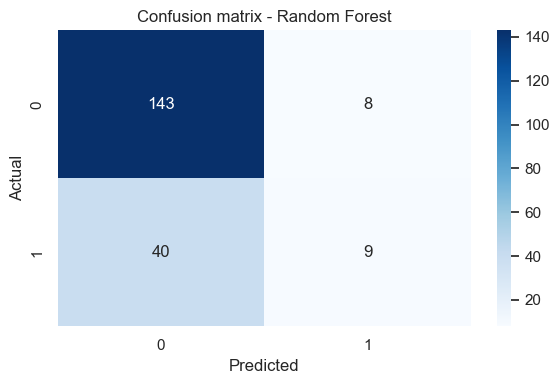


Random Forest report:

              precision    recall  f1-score   support

           0       0.78      0.95      0.86       151
           1       0.53      0.18      0.27        49

    accuracy                           0.76       200
   macro avg       0.66      0.57      0.56       200
weighted avg       0.72      0.76      0.71       200



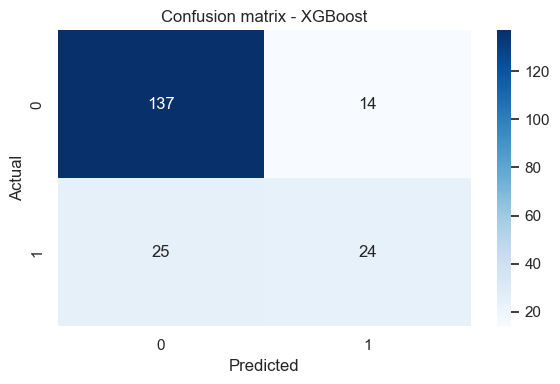


XGBoost report:

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       151
           1       0.63      0.49      0.55        49

    accuracy                           0.81       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.79      0.81      0.80       200



In [9]:
plot_confusion_matrix(y_test, rf_pred, title='Confusion matrix - Random Forest')
print('\nRandom Forest report:\n')
print(classification_report(y_test, rf_pred))

plot_confusion_matrix(y_test, xgb_pred, title='Confusion matrix - XGBoost')
print('\nXGBoost report:\n')
print(classification_report(y_test, xgb_pred))


## 6) (Optional) Tune XGBoost

GridSearchCV can take a long time. Set `RUN_TUNING=True` if you want to run it.


--- Tuning XGBoost hyperparameters ---
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV recall: 0.7429

Tuned model metrics:
--- Performance metrics ---
Classification report:
              precision    recall  f1-score   support

      Normal       0.89      0.87      0.88       151
       Fraud       0.62      0.65      0.63        49

    accuracy                           0.81       200
   macro avg       0.75      0.76      0.75       200
weighted avg       0.82      0.81      0.82       200

ROC-AUC: 0.8398
PR-AUC (average precision): 0.5536


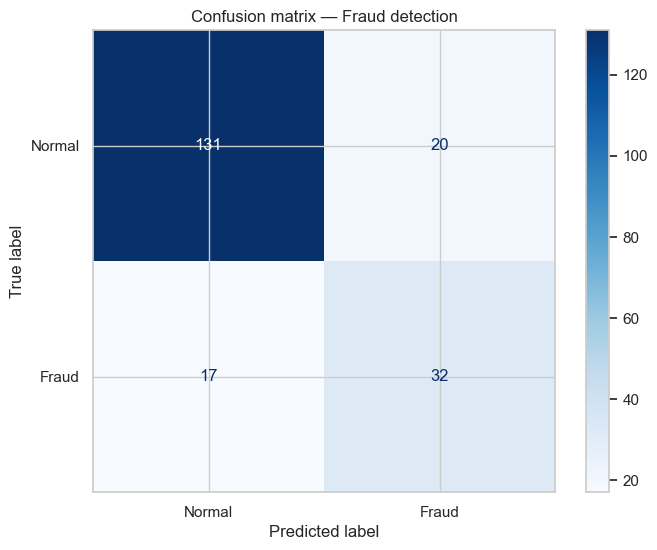

In [10]:
best_xgb_model = None

if RUN_TUNING:
    best_xgb_model = tune_xgboost(X_train_final, y_train_final)
    print("\nTuned model metrics:")
    _ = evaluate_model_performance(best_xgb_model, X_test, y_test)


## 7) Assessment (metrics + curves)

Run evaluation for the selected model. By default it uses the tuned XGBoost if available, otherwise the baseline XGBoost.


--- Performance metrics ---
Classification report:
              precision    recall  f1-score   support

      Normal       0.89      0.87      0.88       151
       Fraud       0.62      0.65      0.63        49

    accuracy                           0.81       200
   macro avg       0.75      0.76      0.75       200
weighted avg       0.82      0.81      0.82       200

ROC-AUC: 0.8398
PR-AUC (average precision): 0.5536


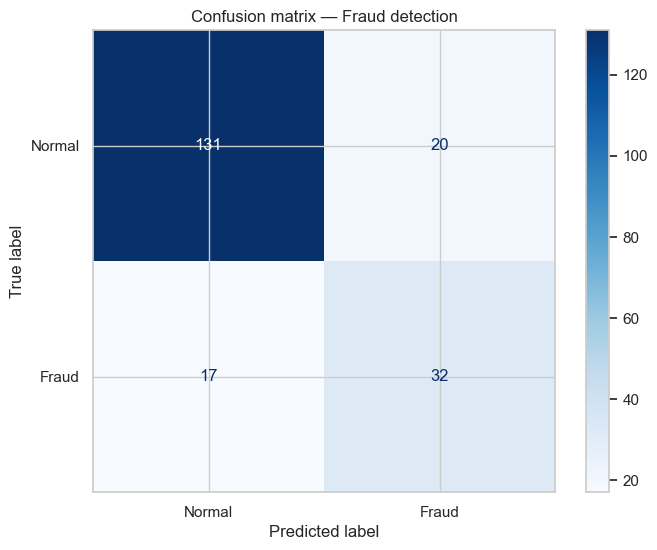

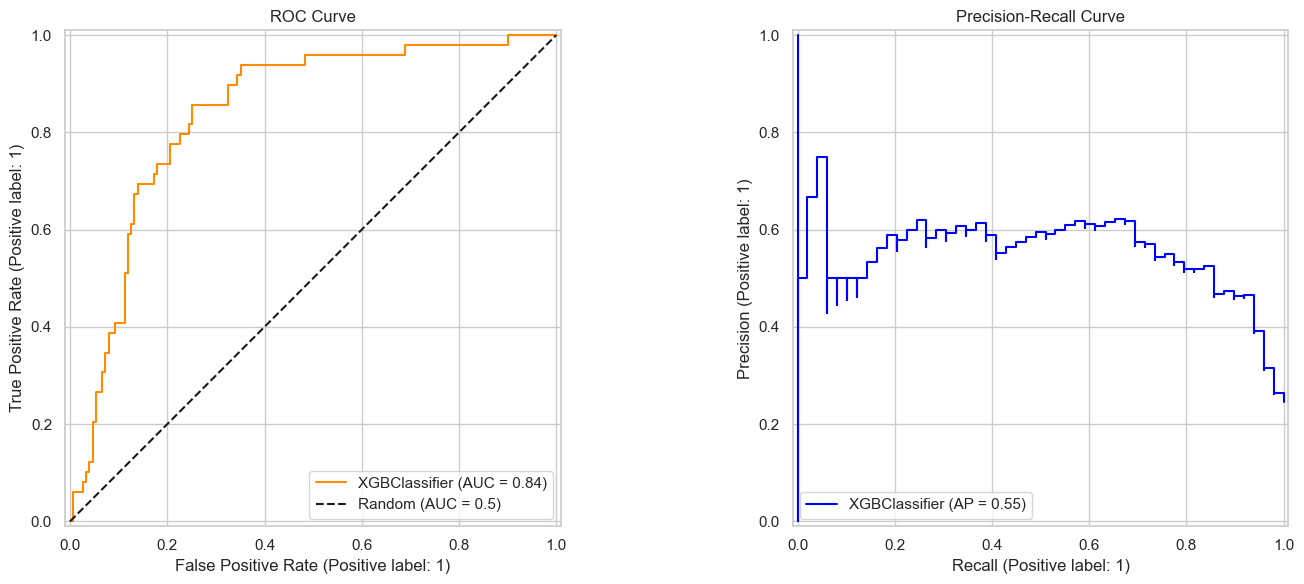

{'roc_auc': 0.8398432220570347, 'pr_auc': 0.5536193477252874}

In [11]:
if USE_SAVED_MODEL:
    model_for_assessment = load_model(SAVED_MODEL_FILENAME)
else:
    model_for_assessment = best_xgb_model if best_xgb_model is not None else xgb_model

if RUN_ASSESSMENT:
    metrics = evaluate_model_performance(model_for_assessment, X_test, y_test)
    plot_all_curves(model_for_assessment, X_test, y_test)
else:
    metrics = None

metrics


## 8) Precision-Recall curve + save model


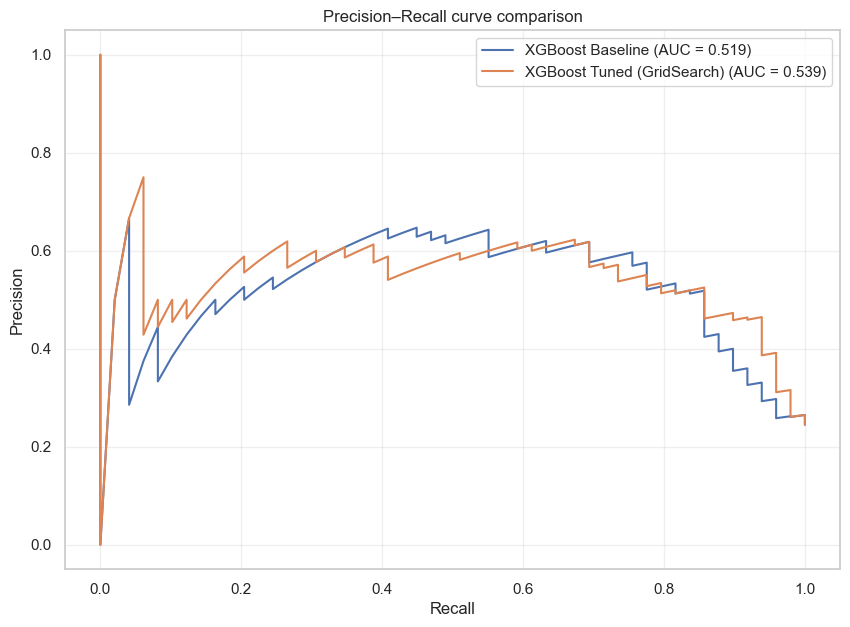

Model saved to /Users/admin/Documents/Side Project/Insurance_Project/src/models/best_xgboost_v1.pkl


In [12]:
models_to_compare = {"XGBoost Baseline": xgb_model}
if best_xgb_model is not None:
    models_to_compare["XGBoost Tuned (GridSearch)"] = best_xgb_model

plot_pr_comparison(models_to_compare, X_test, y_test)

model_to_save = best_xgb_model if best_xgb_model is not None else xgb_model
if SAVE_MODEL:
    save_model(model_to_save, "best_xgboost_v1.pkl")


## 9) Interpretability with 'SHAP'


--- 🔍 Interpreting Model with SHAP ---


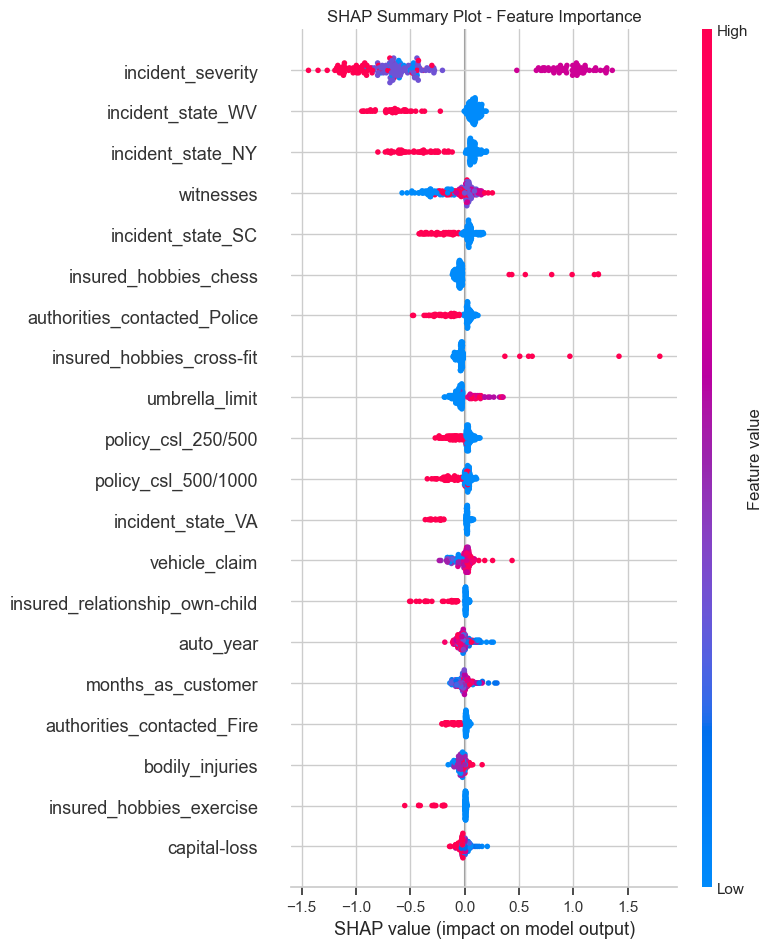

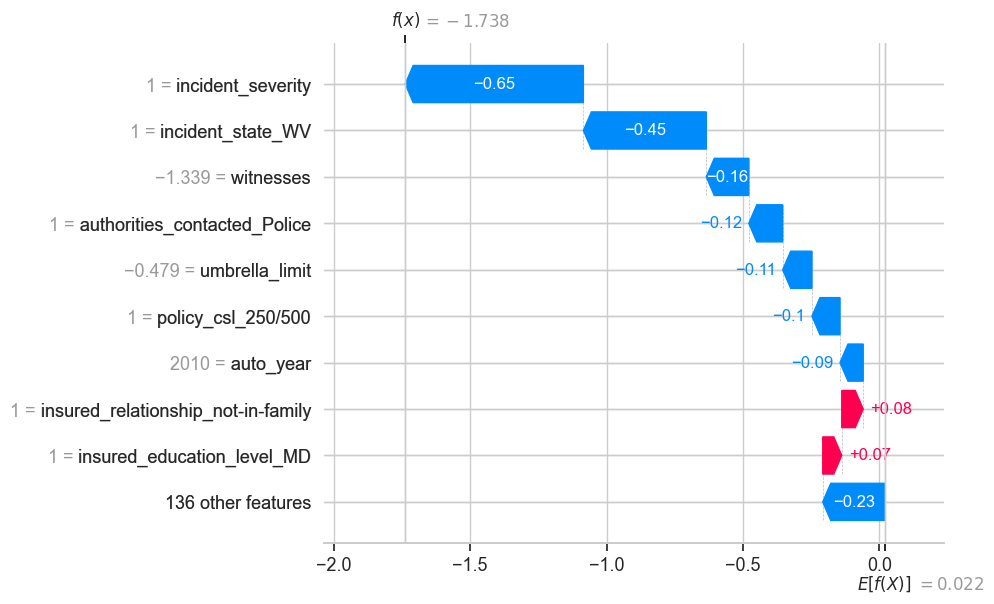

In [13]:
import shap
explainer, shap_values = interpret_with_shap(best_xgb_model, X_train, X_test)
shap.plots.waterfall(shap_values[0])